##### STA 220 Data & Web Technologies for Data Analysis

### Lecture 13, 02/17/26, Visualization

- Static plots
- Interactive plots
- Cartography, e.g. choropleth maps


### Announcements
- Presentation order is available online, all groups registered. (Thanks!)
- Second homework assignment due February 20.

### Today's topics
- Static plots:
    - Plotnine
    - Matplotlib and Seaborn
    - (a little bit of Pandas.plot)
- Immage processing
- Cartography introduction
 
### Data Sets

 - `dogs_full.csv`
 - `fluidmilk.xlsx`
 - `yolo_food.feather`

### Preliminaries

To show the plots in Jupyter notebook, use the following command:

In [1]:
%matplotlib inline

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Static plots

Our focus right now is _static_ visualization, where the visualization is a still image. So what packages should you actually use?

* __plotnine__ is convenient if you already know ggplot2. It's relatively new, so there are some bugs and missing features. In fact, ggplot2 is abstracting data visualization into different tasks and handling them seperately in a very clean way. It was introduced by the genius [Hadley Wickham](https://hadley.nz/).

* __seaborn__ is designed specifically for making statistical plots. It's well-documented and stable. Most of the package's functions expect tidy data as input.

* __matplotlib__ is useful to know, since many other packages use matplotlib under the hood. That said, using matplotlib alone to create plots is painful; matplotlib is _low-level_, so it's flexible but simple plots may take [5 lines of code or more][ex]. The matplotlib PyPlot tools may be convenient if you already know MATLAB.

* __pandas__ provides built-in plotting functions, which can be convenient but are more limited than the packages above. They're also inconsistent about the expected format of the data.

We don't have time to exhaustively cover visualization packages for Python. You're welcome to explore other packages while doing the assignments for this class.

Next week, we'll see some of Python's _interactive_ visualization packages.

[ex]: https://dsaber.com/2016/10/02/a-dramatic-tour-through-pythons-data-visualization-landscape-including-ggplot-and-altair/

See the [plotnine documentation](https://plotnine.readthedocs.io/en/latest/)! Also see the [ggplot2 documentation](https://ggplot2.tidyverse.org/reference/) and the [ggplot2 cheatsheet](https://www.maths.usyd.edu.au/u/UG/SM/STAT3022/r/current/Misc/data-visualization-2.1.pdf). If you run into a bug, you may want to check for a work-around on the [plotnine bug tracker](https://github.com/has2k1/plotnine/issues).

### Matplotlib

The next two examples are taken from the fifth discussion section. Find it on Canvas.

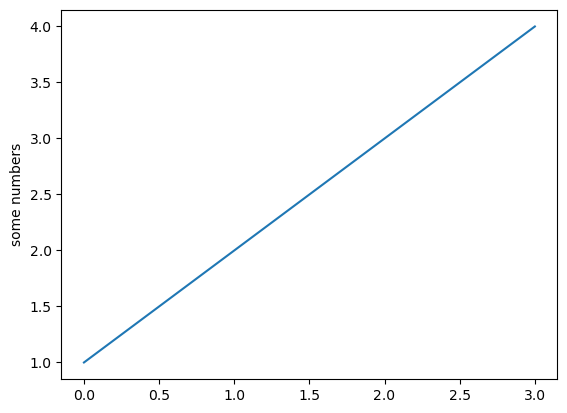

In [6]:
import matplotlib.pyplot as plt

plt.plot([1, 2, 3, 4])
plt.ylabel('some numbers')
plt.show()

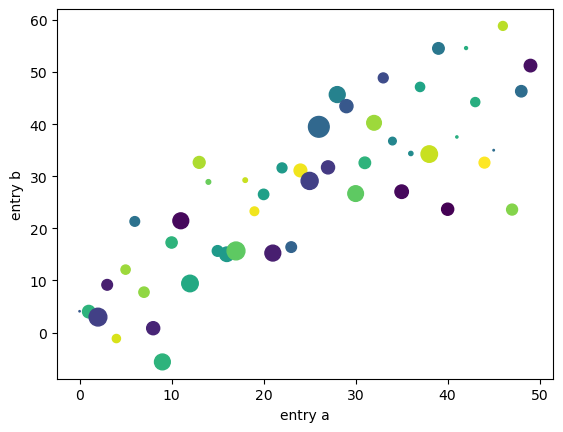

In [7]:
data = {'a': np.arange(50),
        'c': np.random.randint(0, 50, 50),
        'd': np.random.randn(50)}
data['b'] = data['a'] + 10 * np.random.randn(50)
data['d'] = np.abs(data['d']) * 100

plt.scatter('a', 'b', c='c', s='d', data=data)  ## c: color/color map; s: size
plt.xlabel('entry a')
plt.ylabel('entry b')
plt.show()

## Pandas plot

[Cheatsheet](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf) and a little bit more details

In [8]:
# Import
df_raw = pd.read_csv("https://github.com/selva86/datasets/raw/master/mpg_ggplot2.csv")

# Prepare Data
df = df_raw.groupby('class').size()
df

class
2seater        5
compact       47
midsize       41
minivan       11
pickup        33
subcompact    35
suv           62
dtype: int64

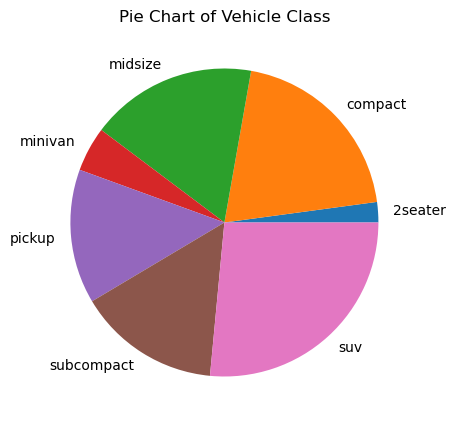

In [9]:
# Make the plot with pandas
df.plot(kind='pie', figsize=(5, 5))
plt.title("Pie Chart of Vehicle Class")
plt.show()
plt.close()

## Seaborn

Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.

Seaborn library is included as part of the Anaconda distribution.

See the [seaborn documentation](https://seaborn.pydata.org/) and the introduction [therein](https://seaborn.pydata.org/tutorial/introduction.html)!

In [10]:
import seaborn as sns

sns.__version__

'0.13.2'

### Seaborn Grammar and Common Functions

Seaborn is a Python library for statistical data visualization, built on top of Matplotlib. It simplifies the creation of complex visualizations with minimal code and provides support for informative, aesthetic plots.

#### Key Grammar of Seaborn
1. **Dataset-Oriented:** Seaborn works directly with Pandas DataFrames, making it easy to visualize relationships between variables.
2. **Aesthetics (x, y, hue, size, style):** Mappings between data variables and visual properties like color (`hue`), size, and line style.
3. **Statistical Estimation:** Many functions automatically compute and plot aggregate statistics (e.g., means, confidence intervals).
4. **Themes:** Built-in themes (`set_style`) make plots visually appealing and consistent.
5. **Facets:** `FacetGrid` enables creation of subplots for subsets of data.

#### Common Seaborn Functions
1. `sns.scatterplot()`: Scatter plot.
2. `sns.lineplot()`: Line plot.
3. `sns.barplot()`: Bar chart with aggregated data.
4. `sns.histplot()`: Histogram.
5. `sns.boxplot()`: Box plot.
6. `sns.violinplot()`: Violin plot.
7. `sns.heatmap()`: Heatmap for matrix data.
8. `sns.pairplot()`: Pairwise plots for numerical relationships.
9. `sns.catplot()`: Plot for categorical data.

#### Example: Plotting with Seaborn
The following example creates a scatter plot with the `penguins` dataset.

In seaborn, the __hue__ parameter determines which column in the data frame should be used for colour encoding. 

In [11]:
%matplotlib inline

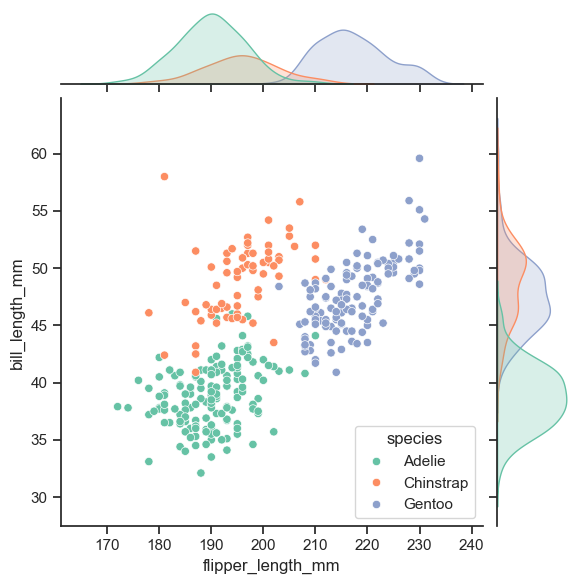

In [12]:
# Importing necessary libraries
import seaborn as sns
import pandas as pd

# Load example dataset
penguins = sns.load_dataset("penguins")

sns.set_theme(style = 'ticks', palette = 'Set2')
ax = sns.jointplot(data=penguins, x="flipper_length_mm", y="bill_length_mm", hue="species")
plt.show()
plt.close()

In [14]:
# Import Data
df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/mpg_ggplot2.csv")
df_select = df.loc[df.cyl.isin([4,8]), :] # only choose 4 and 8 cylinders

df.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact


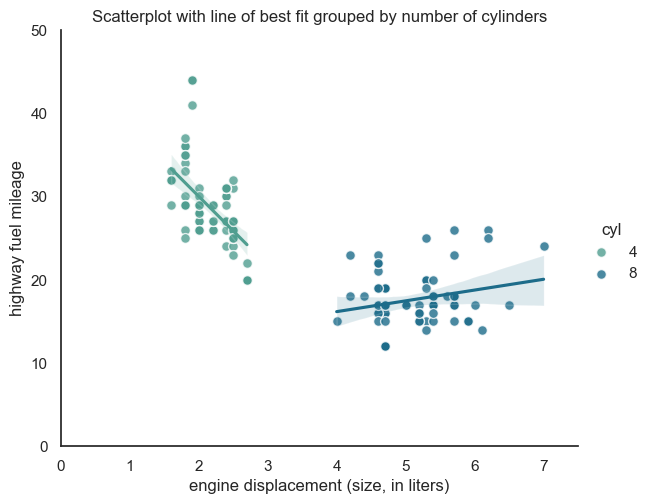

In [16]:
# Plot
sns.set_style("white")
gridobj = sns.lmplot(x="displ", y="hwy", hue="cyl", data=df_select, 
                     height=5, aspect=1.2, robust=False, palette='crest', # height*aspect = width
                     scatter_kws=dict(s=50, linewidths=1, edgecolors='white'), # s = size of circles
                     truncate = True) # line does end at last data point
 
# Decorations
gridobj.set(xlim=(0, 7.5), ylim=(0, 50))
plt.title("Scatterplot with line of best fit grouped by number of cylinders", fontsize=12)
plt.ylabel('highway fuel mileage')
plt.xlabel('engine displacement (size, in liters)')
plt.show()
plt.close()

## Plotnine

We start with the plotnine package, an implementation of ggplot2 for Python. Unlike packages we've seen so far, plotnine is not included with Anaconda. To install the package:

* On Windows, run `conda install -c conda-forge plotnine` in an Anaconda Prompt (find it in the start menu)
* On MacOS or Linux, run `conda install -c conda-forge plotnine` in the Terminal

You may have to restart Jupyter after installing. 

In [17]:
!pip install plotnine

In [18]:
import plotnine as p9

p9.__version__

'0.15.0'

[Plotnine Cheatsheet](https://github.com/rstudio/cheatsheets/blob/main/plotnine.pdf)

### Plotnine Grammar and Common Layers

#### Key Grammar of Plotnine
Plotnine implements the grammar of graphics, where a plot is constructed in layers:
1. **Data:** The dataset to be visualized.
2. **Aesthetics (aes):** Mappings between variables in the data and visual properties (e.g., `x`, `y`, `color`).
3. **Geometric Objects (geoms):** The type of plot elements to display (e.g., `geom_line`, `geom_point`).
4. **Facets:** Create multiple subplots for subsets of data.
5. **Scales:** Define how data values map to visual properties.
6. **Themes:** Customize the appearance of the plot.

#### Common Layers in Plotnine
1. `geom_point()`: Scatter plot.
2. `geom_line()`: Line plot.
3. `geom_bar(stat='identity')`: Bar chart.
4. `geom_histogram()`: Histogram.
5. `geom_boxplot()`: Box plot.
6. `facet_wrap(~var)`: Facet by a variable.
7. `scale_color_manual()`: Custom colors for categories.
8. `labs(title, x, y)`: Add labels and title.
9. `theme_*`: Customize themes (e.g., `theme_minimal()`).

#### Example: Plotting with Plotnine
The following example creates a line plot with the `milk` dataset.

The syntax of plotnine closely follows the syntax of R's ggplot2. In R, we would write

```r
ggplot(milk, aes(x = Year, y = Sales, color = Kind)) + geom_line() 
```

One important difference is that plotnine requires that we quote variable names.

In [19]:
import numpy as np
import pandas as pd

milk = pd.read_excel("../data/fluidmilk.xlsx", skiprows = 1)
milk.head(4)

,Unnamed: 0,Whole,Reduced-fat \n(2% milk fat),Low-fat \n(1% milk fat),Skim,Flavored \nwhole 1,"Flavored, \nother than whole",Buttermilk,Eggnog,Total 2
0,1975,36188.0,8726.0,2742.0,2480.0,1366.0,719.0,1011.0,76.0,53308.0
1,1976,35241.0,9556.0,2875.0,2524.0,1475.0,864.0,1021.0,87.0,53643.0
2,1977,34036.0,10423.0,3003.0,2617.0,1446.0,1062.0,1007.0,94.0,53688.0
3,1978,33235.0,11017.0,3233.0,2543.0,1359.0,1097.0,983.0,94.0,53561.0


In [20]:
milk.columns = milk.columns.str.replace('\n', '')
milk = milk.rename(columns=lambda df: df.strip(' 12'))
milk.columns.values[[0,2,3,5,6]] = np.array(['Year', 'Reduced', 'Low', 
                                             'Flavored Whole', 'Flavored Other'])
milk = milk[:-4] # get rid of the last four rows
milk = milk.drop(columns = 'Total')

milk['Year'] = pd.to_numeric(milk['Year'])

milk = milk.set_index("Year") 

milk1 = milk.stack()
milk1 = milk1.reset_index()
milk1.columns.values[[False, True, True]] = np.array(["Kind", "Sales"])

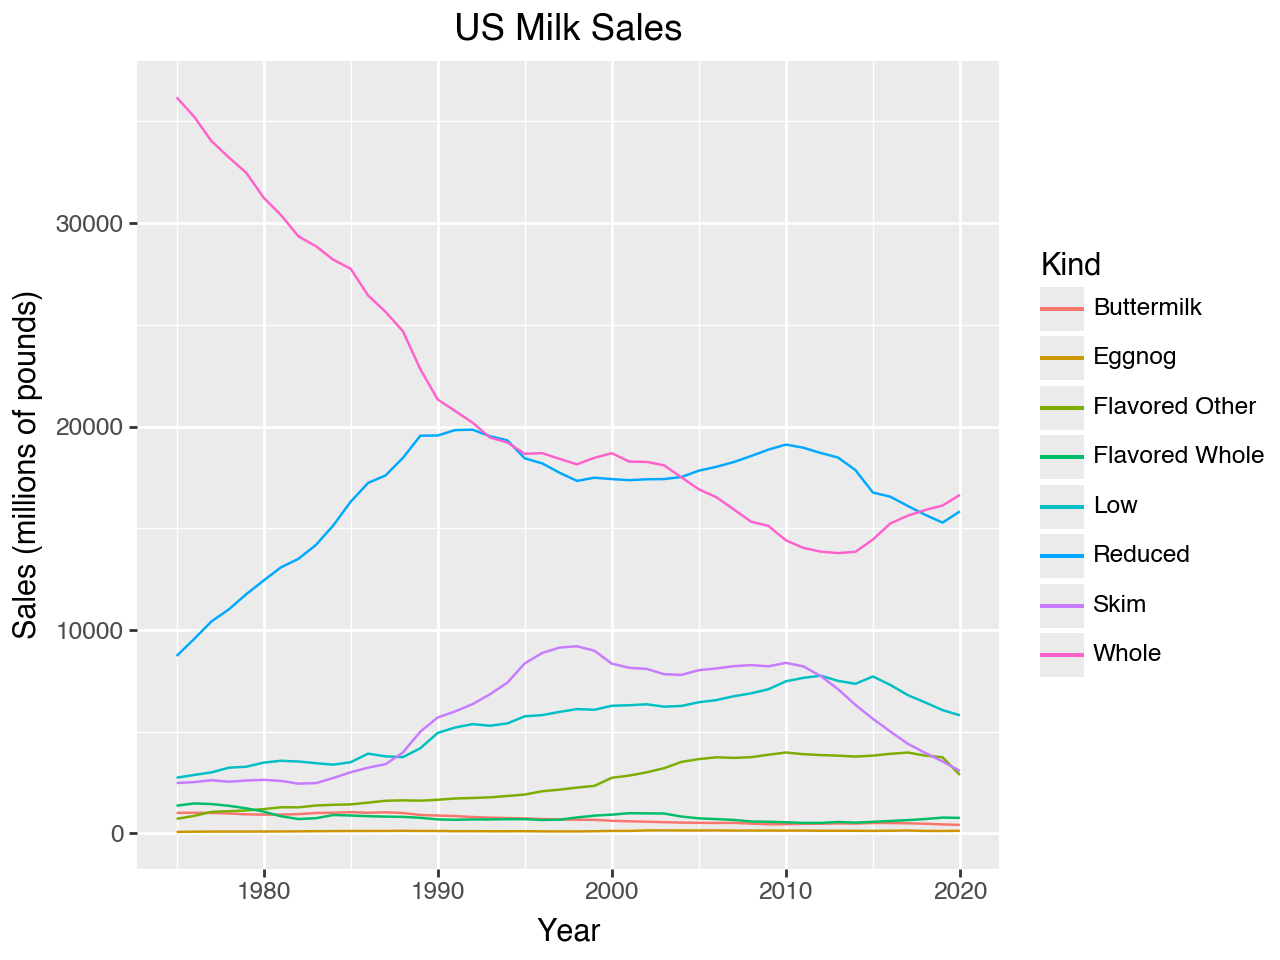

In [25]:
p = (
    p9.ggplot(milk1, p9.aes(x="Year", y="Sales", color="Kind"))  
        # Create a ggplot object:
        #   - milk1: The DataFrame containing the data to plot
        #   - p9.aes(): Defines the aesthetic mappings:
        #       - x="Year": Maps the 'Year' column to the x-axis
        #       - y="Sales": Maps the 'Sales' column to the y-axis
        #       - color="Kind": Maps the 'Kind' column to different colors 
    + p9.geom_line()  # Add a line geometry to the plot, connecting data points with lines
    + p9.labs(title="US Milk Sales", y="Sales (millions of pounds)")  
        # Add labels to the plot:
        #   - title: Sets the title of the plot
        #   - y: Sets the label for the y-axis
    + p9.theme_gray() # theme_classic(), theme_void(), theme_gray(
#    + p9.scale_color_brewer("qualitative", palette="Dark2")
)
p

# Image processing

In [26]:
# Automatically display matplotlib plots, so that we don't have to write `plt.show()`.
# Normally this should be in a cell at the top of the notebook.
# %matplotlib inline

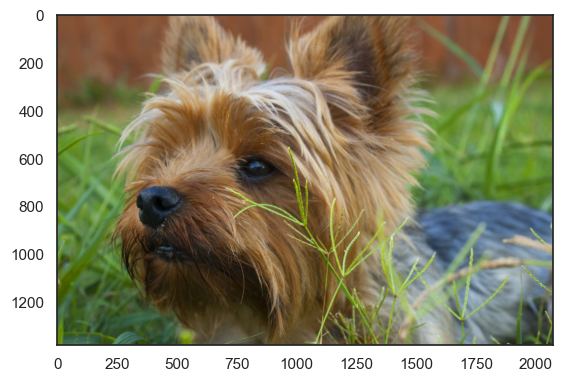

In [27]:
import matplotlib.pyplot as plt
import matplotlib.image as img

# Dog image from https://unsplash.com/photos/jx_kpR7cvDc
dog = img.imread("../images/dog.png")
plt.imshow(dog) # render image
plt.show()

In [28]:
type(dog)

numpy.ndarray

In [29]:
dog.shape

(1378, 2073, 3)

In [30]:
dog[:3,:3,:]

array([[[0.5137255 , 0.32941177, 0.21960784],
        [0.5137255 , 0.32941177, 0.21960784],
        [0.5137255 , 0.32941177, 0.21960784]],

       [[0.5137255 , 0.32941177, 0.21960784],
        [0.5137255 , 0.32941177, 0.21960784],
        [0.5137255 , 0.32941177, 0.21960784]],

       [[0.5137255 , 0.32941177, 0.21960784],
        [0.5137255 , 0.32941177, 0.21960784],
        [0.5137255 , 0.32941177, 0.21960784]]], dtype=float32)

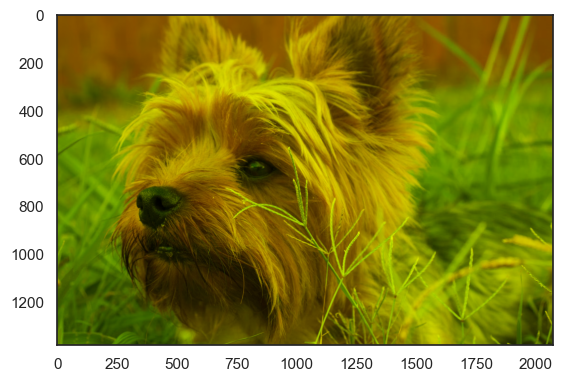

In [31]:
dog_rg = dog.copy()
dog_rg[:,:,2] = 0 # set blue to 0
plt.imshow(dog_rg)
plt.show()

Depending on which package you use to load an image, pixels may be encoded as integers or floating point (decimal) numbers. The scikit-image package has [some documentation](http://scikit-image.org/docs/dev/user_guide/data_types.html) about what these numbers typically mean.

In [32]:
dog.dtype

dtype('float32')

Let's try to find all the green pixels and make them red.

How can we do this?

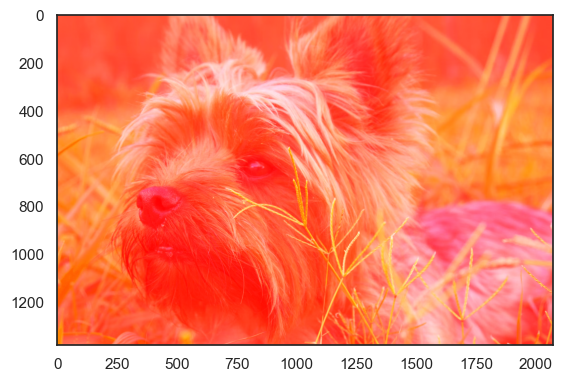

In [33]:
reddog_rgb = dog.copy()
reddog_rgb[:, :, 0] = 1 # Set red channel to large value.
# reddog_rgb[:, :, 1] = 0 # Set green channel to small value.
plt.imshow(reddog_rgb)
plt.show()

Break problems into small steps.

If you're trying to figure out how something works, test on small "toy" examples and draw pictures.

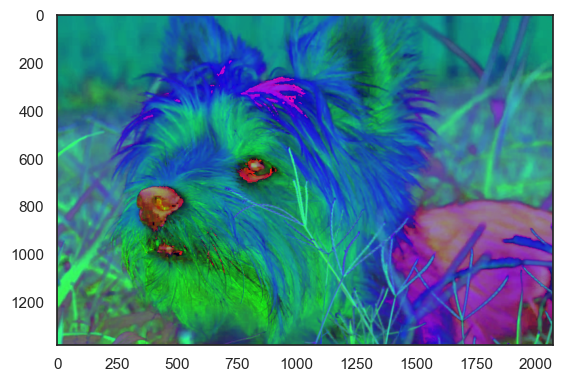

In [34]:
import numpy as np
import skimage as ski
import skimage.color

# Switch from (red, green, blue) to (hue, saturation, value).
# Hue is the color (from red to violet).
# Saturation is how colorful (from colorless to colorful).
# Value is how bright (from black to bright color).
dog_hsv = ski.color.rgb2hsv(dog)
plt.imshow(dog_hsv)
plt.show()

In [35]:
dog_hsv.shape

(1378, 2073, 3)

 Start by taking a small piece of the dog image, say the __lower left corner__.

In [36]:
dog_hsv[:3, :3, :]

array([[[0.06222222, 0.5725191 , 0.5137255 ],
        [0.06222222, 0.5725191 , 0.5137255 ],
        [0.06222222, 0.5725191 , 0.5137255 ]],

       [[0.06222222, 0.5725191 , 0.5137255 ],
        [0.06222222, 0.5725191 , 0.5137255 ],
        [0.06222222, 0.5725191 , 0.5137255 ]],

       [[0.06222222, 0.5725191 , 0.5137255 ],
        [0.06222222, 0.5725191 , 0.5137255 ],
        [0.06222222, 0.5725191 , 0.5137255 ]]], dtype=float32)

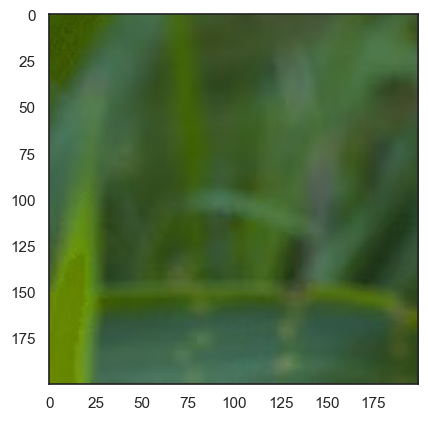

In [37]:
grass = dog_hsv[-200:, :200, :] #dog_hsv[266-50:266, 0:50, :]
plt.imshow(ski.color.hsv2rgb(grass))
plt.show()

How can we figure out what "green" looks like in HSV?

In [38]:
mu = grass.mean(axis = (0, 1))
mu

array([0.29303646, 0.5274062 , 0.38279298], dtype=float32)

We can preview this "green" by making a 2x2 swatch.

In [39]:
swatch = np.stack(4 * [mu]).reshape((2, 2, 3)) # 4 * [mu] creates a list consisting of four times mu
swatch

array([[[0.29303646, 0.5274062 , 0.38279298],
        [0.29303646, 0.5274062 , 0.38279298]],

       [[0.29303646, 0.5274062 , 0.38279298],
        [0.29303646, 0.5274062 , 0.38279298]]], dtype=float32)

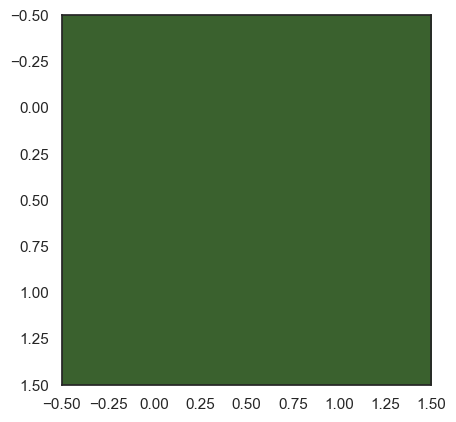

In [40]:
plt.imshow(ski.color.hsv2rgb(swatch))
plt.show()

In [46]:
def plot_swatch(color):
    swatch = np.stack(4 * [color]).reshape((2, 2, 3))
    fig = plt.figure(figsize=(3, 3))
    plt.imshow(ski.color.hsv2rgb(swatch))
    plt.show()

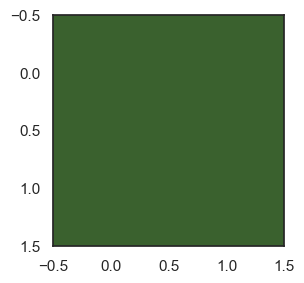

In [47]:
plot_swatch(mu)

Now we need to get all pixels with a hue "nearby" the grass mean.

How can we define "nearby"?

In [48]:
sd = grass.std(axis = (0, 1))
sd

array([0.05297463, 0.17469776, 0.0628553 ], dtype=float32)

In [49]:
tol = (mu[0] - 3 * sd[0], mu[0] + 3 * sd[0])
tol

(np.float32(0.13411258), np.float32(0.45196033))

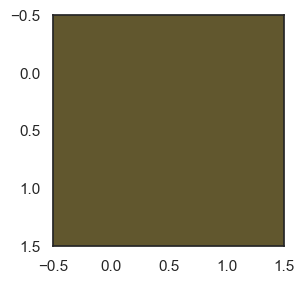

In [50]:
plot_swatch([tol[0], mu[1], mu[2]])

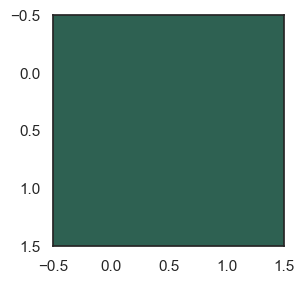

In [51]:
plot_swatch([tol[1], mu[1], mu[2]])

In [52]:
plt.imshow(dog)

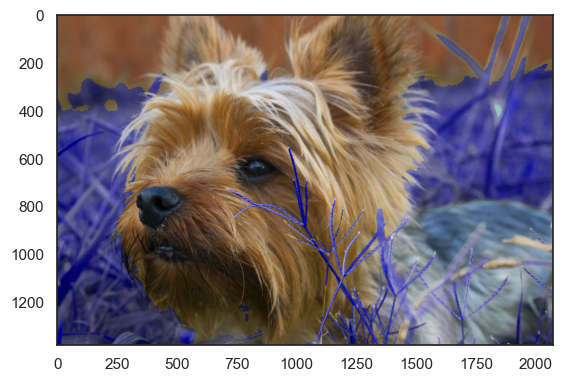

In [84]:
reddog = dog_hsv.copy()
is_green = (tol[0] <= reddog[:, :, 0]) & (reddog[:, :, 0] <= tol[1])
reddog[is_green, 0] = 255 # hue 0 means red, 255 means blue / or floats between 0 and 1
plt.imshow(ski.color.hsv2rgb(reddog))
plt.show()

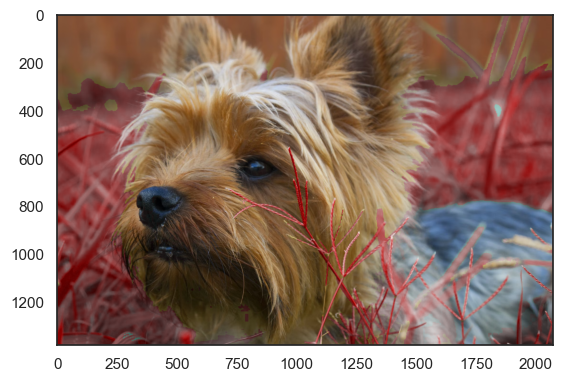

In [85]:
reddog[is_green, 0] = 0 # hue 0 means red, 255 means blue
plt.imshow(ski.color.hsv2rgb(reddog))
plt.show()

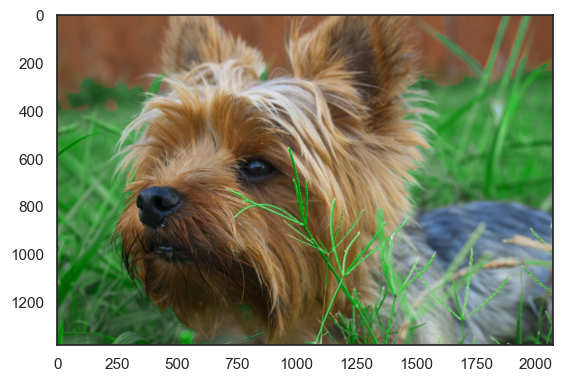

In [88]:
bright_grass = dog_hsv.copy()
is_green = (tol[0] <= bright_grass[:, :, 0]) & (bright_grass[:, :, 0] <= tol[1])
bright_grass[is_green, 0] = 324
plt.imshow(ski.color.hsv2rgb(bright_grass))
plt.show()

What would happen if we tried this with RGB instead of HSV?

Think about the structure, the blade of grass: would we be able to still see them? Why / why not?